<a href="https://colab.research.google.com/github/Mooketsi324/Dataset-for-programing-for-data-analytics/blob/main/PDAN8411_Healthcare_Reviews_POE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libaries imported successfully")

Libaries imported successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving reviews.csv to reviews.csv


In [ ]:
df = pd.read_csv('reviews.csv')

df.head()

,CompanyName,Review,Date,OwnershipType
0,united_american,United American has been fantastic. We have ha...,4/22/2023,Public
1,united_american,We've had very good luck with United American....,10/28/2022,Public
2,united_american,We've had a United American Insurance policy f...,10/12/2022,Public
3,united_american,We were with Cleveland Clinic and when they st...,9/1/2022,Public
4,united_american,My husband worked for a bank and we had a life...,5/30/2022,Public


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10743 entries, 0 to 10742
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CompanyName    10743 non-null  object
 1   Review         10741 non-null  object
 2   Date           10743 non-null  object
 3   OwnershipType  10743 non-null  object
dtypes: object(4)
memory usage: 335.8+ KB


In [ ]:
df.shape

(10743, 4)

In [ ]:
df.columns

Index(['CompanyName', 'Review', 'Date', 'OwnershipType'], dtype='object')

In [ ]:
df.isnull().sum()

,0
CompanyName,0
Review,2
Date,0
OwnershipType,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
# Remove rows with missing values
df= df.dropna()

# Remove duplicated rows
df = df.drop_duplicates()

print("Data cleaned successfully")

Data cleaned successfully


In [ ]:
df.duplicated().sum()

np.int64(0)

Data Cleaning:

Data cleaning was conducted to improve the quality and reliabilty of the dataset. missing values were identified using isnull() function, revealing two missing observations within the Review variable. These records were removed using the dropna() function. Duplicate records were then identified using duplicated() functionm which revealed one duplicated observation. This duplicate record was removed using the drop_duplicates() function. After cleaning, the dataset contained no missing values and no duplicate records, making it suitable for further analysis.

In [ ]:
df.shape

(10740, 4)

In [ ]:
df.columns

Index(['CompanyName', 'Review', 'Date', 'OwnershipType'], dtype='object')

In [ ]:
df['CompanyName'].value_counts().head(10)

,count
CompanyName,
united_health_care,2094
humana,1798
kaiser,1259
cigna_health,1167
aetna_health,1117
bluecross,949
anthem,613
wellcare,443
health_net,420


In [ ]:
df['Review_Length'] = df['Review'].astype(str).apply(len)

df['Review_Length'].describe()

,Review_Length
count,10740.000000
mean,1021.809963
std,906.644181
min,29.000000
25%,445.000000
50%,756.000000
75%,1280.250000
max,11145.000000


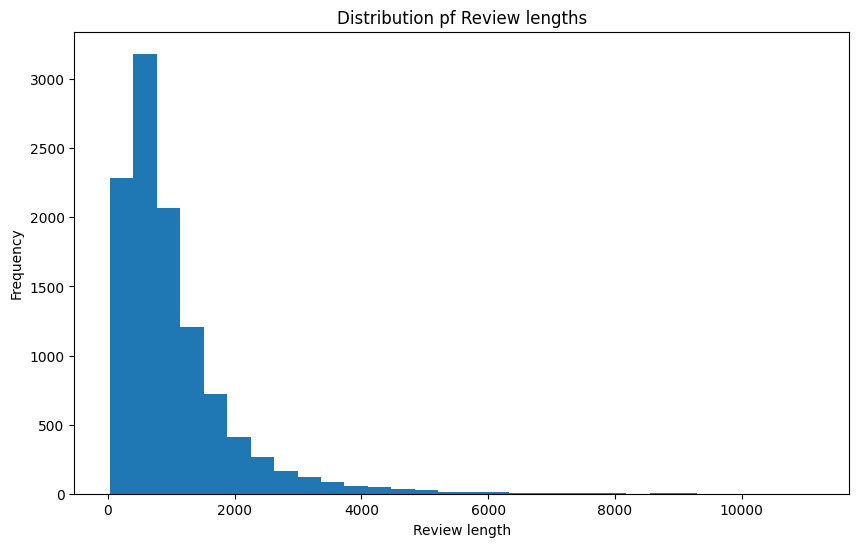

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['Review_Length'], bins=30)
plt.title('Distribution pf Review lengths')
plt.xlabel('Review length')
plt.ylabel('Frequency')
plt.show()

Review Length Analysis:

A histogram was generated to examine the distribution of review lengths. The results indicate a positively skewed distribution, with the majority of customer reviews being relatively short to medium in length. A small number of reviews were significantly longer than the average review, suggesting that some customers provided detailed descriptions of their experiences. Understanding review length is important because longer reviews often contain more detailed information regarding customer concerns and service experiences.

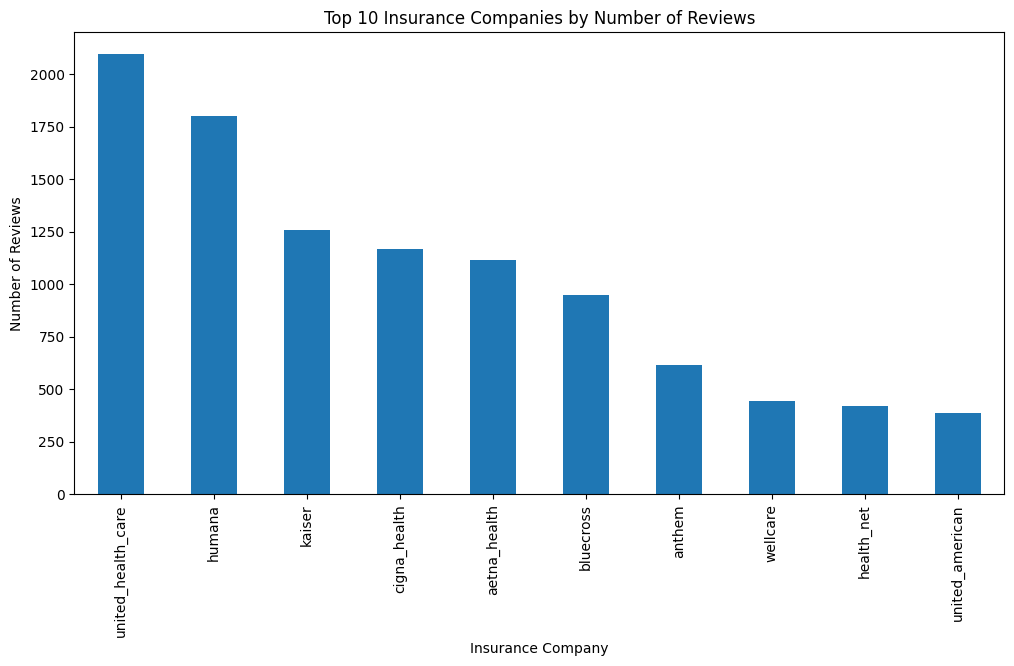

In [ ]:
plt.figure(figsize=(12,6))

df['CompanyName'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Insurance Companies by Number of Reviews')
plt.xlabel('Insurance Company')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
df['CompanyName'].value_counts().head(10)

,count
CompanyName,
united_health_care,2094
humana,1798
kaiser,1259
cigna_health,1167
aetna_health,1117
bluecross,949
anthem,613
wellcare,443
health_net,420


The dataset contains reviews from mulitple healthcare insurance providers. The top ten companies were identified based on review frequency. Understanding the distribution of reviews across companies assists in determing which providers generate the largest volume of customer feedback

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = reb.sub(r'[^a-zA-Z\s]','',text)
    return text

    df ['Clean_Review'] = df['Review']. apply(clean_text)

    df[['Review','Clean_Review']].head()

In [ ]:
df.columns

Index(['CompanyName', 'Review', 'Date', 'OwnershipType', 'Review_Length'], dtype='object')

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]','', text)
    return text


df['Clean_Review'] = df['Review']. apply(clean_text)

df.columns



Index(['CompanyName', 'Review', 'Date', 'OwnershipType', 'Review_Length',
       'Clean_Review'],
      dtype='object')

In [ ]:
from collections import Counter

all_words = ' '.join(df['Clean_Review'])

word_counts = Counter(all_words.split())

word_counts.most_common(20)

[('i', 74980),
 ('the', 71714),
 ('to', 70466),
 ('and', 56291),
 ('a', 42569),
 ('my', 34986),
 ('they', 29826),
 ('for', 28856),
 ('of', 28326),
 ('that', 27395),
 ('was', 24360),
 ('have', 22533),
 ('in', 21455),
 ('is', 20791),
 ('not', 18227),
 ('it', 18224),
 ('me', 17712),
 ('with', 17631),
 ('this', 16957),
 ('on', 16148)]

In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download( 'stopwords')

stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in all_words.split()
    if word not in stop_words
]

filtered_counts = Counter(filtered_words)

filtered_counts.most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('insurance', 10090),
 ('get', 8594),
 ('would', 7644),
 ('told', 6758),
 ('pay', 5725),
 ('called', 5711),
 ('health', 5687),
 ('doctor', 5633),
 ('time', 5464),
 ('company', 5400),
 ('one', 5399),
 ('care', 5395),
 ('call', 5259),
 ('said', 4566),
 ('plan', 4383),
 ('back', 4222),
 ('humana', 4080),
 ('service', 3862),
 ('even', 3806),
 ('never', 3768)]

An initial frequency analysis of the review text revealed that the most common words were standard English stop words such as "the", "and", "to", and "of". These words do not provide meaningful insight into customer concerns and were therefore removed during text preprocessing. stop-word removal allowed the analysis to focus on healthcare-related terms that better represent customer experiences and service concerns.

In [ ]:
filtered_counts.most_common(20)

[('insurance', 10090),
 ('get', 8594),
 ('would', 7644),
 ('told', 6758),
 ('pay', 5725),
 ('called', 5711),
 ('health', 5687),
 ('doctor', 5633),
 ('time', 5464),
 ('company', 5400),
 ('one', 5399),
 ('care', 5395),
 ('call', 5259),
 ('said', 4566),
 ('plan', 4383),
 ('back', 4222),
 ('humana', 4080),
 ('service', 3862),
 ('even', 3806),
 ('never', 3768)]

In [ ]:
!pip install wordcloud

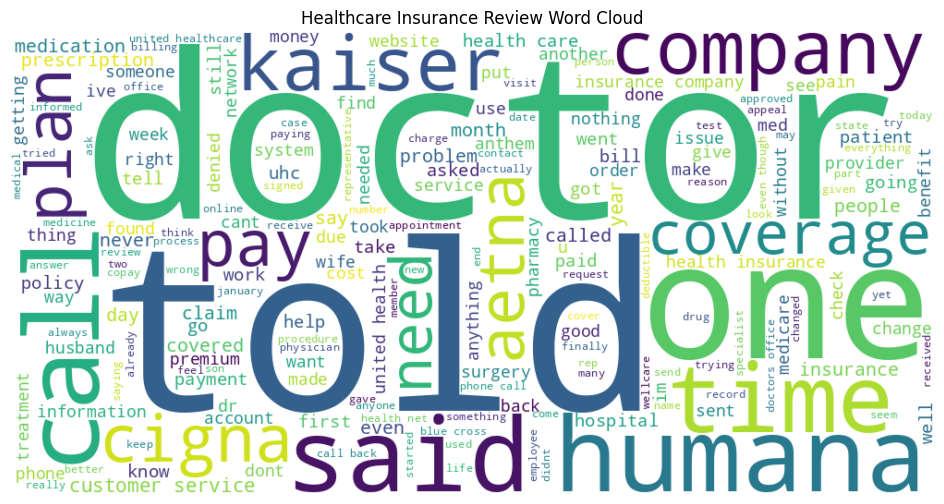

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(' '.join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Healthcare Insurance Review Word Cloud')
plt.show()



In [ ]:
from textblob import TextBlob

def get_sentiment(text):
  polarity = TextBlob(str(text)).sentiment.polarity

  if polarity > 0:
    return "Positive"
  elif polarity < 0:
      return "Negative"
  else:
      return "Neutral"

df['Sentiment'] = df['Review'].apply(get_sentiment)

df['Sentiment'].value_counts()

,count
Sentiment,
Positive,5820
Negative,4598
Neutral,322


In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,5820
Negative,4598
Neutral,322


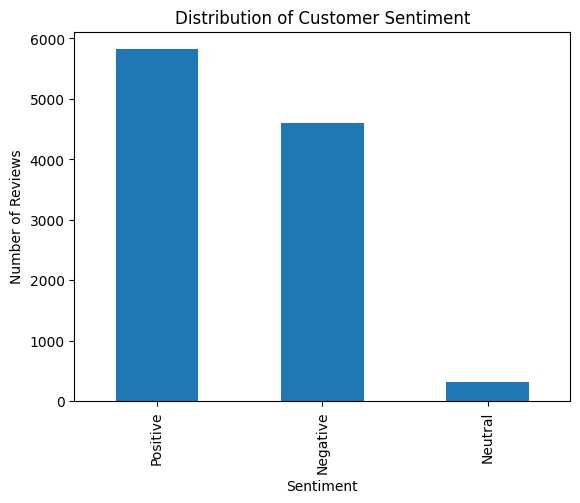

In [ ]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title('Distribution of Customer Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

x = df['Clean_Review']
y = df['Sentiment']

vectorizer = TfidfVectorizer(max_features=5000)

x_vectorized = vectorizer.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(
    x_vectorized,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)



(8592, 5000)
(2148, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.6778398510242085
              precision    recall  f1-score   support

    Negative       0.81      0.41      0.55       939
     Neutral       0.00      0.00      0.00        55
    Positive       0.64      0.93      0.76      1154

    accuracy                           0.68      2148
   macro avg       0.48      0.45      0.43      2148
weighted avg       0.70      0.68      0.65      2148



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


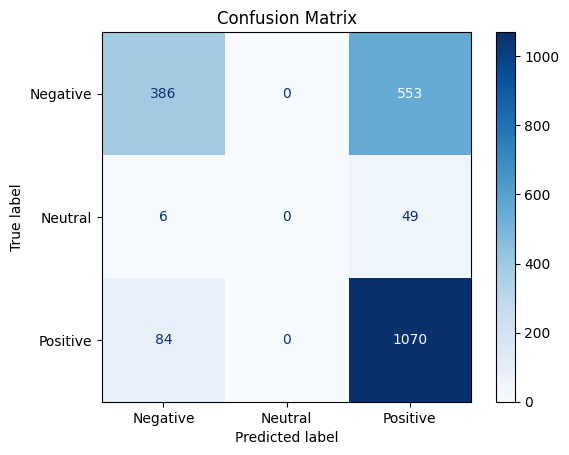

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()
